#### 1. Setup MODE
Prints the repo root path (e.g.../Automation/ode-workflow)

Choose MODEL
- Kapitanov: describes receptor occupancy at site of action for Dupilumab use
- Walz: describes TARC reduction for Dupilumab use
- Tiraboschi: describes EASI reduction for Amlitelimab use
          
MODE options
- run_missing: skip runs that already have "run_summary.json" file
- overwrite: rerun everything even if outputs exist
- load_only: just read existing summaries (no simulation)

In [21]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pandas  # <- use "pandas" name to avoid accidental overwrite
import h5py
import matplotlib.pyplot as plt
import importlib

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

# New canonical import
from scripts.runner import load_config, run_timecourse_reference

MODEL = "Tiraboschi"  # "Kapitanov" | "Walz" | "Tiraboschi"
MODE  = "run_missing"  # "run_missing" | "overwrite" | "load_only"
workers = 8


#### 2. Define parameters + RUN
Choose between Single Dose "SD" and Steady State "SS" simulation
- SD simulates a range of doses (mg/kg) over a defined period 
- SS simulates 25 applications of one dose (mg(kg) at a defined interval (weeks)

Single Dose
- Takes a list of doses in mg/kg
    - dose_values = []
- Use time_weeks to define the simulated period

Single Dose
- Takes a float as dose in mg/kg
- Use interval_values to define the simulated period

Parameters can be changed
- e.g. param_overrides = {"Km_ugml": 0.07}

Run
- Expected runs should match found runs
- Prints missing items, if present 

In [22]:
# -------------------------
# INPUT (edit only here)
# -------------------------

# "SS" (steady state, n=25) | "SD" (single dose, n=1)
T_END_MODE = "SD"

time_weeks = 20  # SS: dosing period; SD: simulation horizon

# For SD: list of doses (mg/kg)
# For SS: single dose (float) ONLY
dose_mgkg = [0.01, 0.1, 1, 10]  # SD: list
# dose_mgkg = 3.0               # SS: float

param_overrides = {}  # override YAML params only

# -------------------------
# VALIDATION / TARGETS
# -------------------------
from pathlib import Path

if T_END_MODE not in ("SS", "SD"):
    raise ValueError("T_END_MODE must be 'SS' or 'SD'")

if T_END_MODE == "SS":
    if isinstance(dose_mgkg, (list, tuple)):
        raise ValueError("For SS, dose_mgkg must be a single float (not a list).")
    dose_list = [float(dose_mgkg)]
    n_doses_override = 25
    pk_only = False
else:
    if not isinstance(dose_mgkg, (list, tuple)):
        raise ValueError("For SD, dose_mgkg must be a list/tuple of doses.")
    dose_list = [float(x) for x in dose_mgkg]
    n_doses_override = 1
    pk_only = False  # <-- IMPORTANT: you want same pd_key as SS

targets = [(d, int(time_weeks)) for d in dose_list]

print("Mode:", T_END_MODE)
print("Time (weeks):", time_weeks)
print("Doses (mg/kg):", dose_list)
print("Overrides:", param_overrides)

# -------------------------
# RUN / LOAD
# -------------------------
from scripts.runner import load_config, run_timecourse_reference

config_map = {
    "Kapitanov": repo_root / "configs/Kapitanov_sweep.yaml",
    "Walz": repo_root / "configs/Walz_sweep.yaml",
    "Tiraboschi": repo_root / "configs/Tiraboschi_sweep.yaml",
}
config_path = config_map[MODEL]
cfg = load_config(config_path)

runs = []
for d, pw in targets:
    if MODE in ("run_missing", "overwrite"):
        summary = run_timecourse_reference(
            config_path=config_path,
            dose_mgkg=d,
            interval_weeks=pw,                 # runner still uses interval_weeks name internally
            param_overrides=param_overrides,
            n_doses_override=n_doses_override,
            pk_only=pk_only,
            overwrite=(MODE == "overwrite"),   # now supported
        )
        run_dir = Path(summary["_run_dir"])
    else:
        raise RuntimeError("For now, please use MODE='run_missing' or 'overwrite' for this notebook.")

    runs.append({"dose_mgkg": d, "time_weeks": pw, "run_dir": run_dir, "summary": summary})

print("Prepared runs:")
for r in runs:
    print(" ", r["run_dir"])


Mode: SD
Time (weeks): 20
Doses (mg/kg): [0.01, 0.1, 1.0, 10.0]
Overrides: {}
Prepared runs:
  C:\Users\LevinSchöpfer\Automation\ode-workflow\results\Tiraboschi_timecourse\params_09c41cacf385\0.01mgkg_q20w_n1
  C:\Users\LevinSchöpfer\Automation\ode-workflow\results\Tiraboschi_timecourse\params_09c41cacf385\0.1mgkg_q20w_n1
  C:\Users\LevinSchöpfer\Automation\ode-workflow\results\Tiraboschi_timecourse\params_09c41cacf385\1.0mgkg_q20w_n1
  C:\Users\LevinSchöpfer\Automation\ode-workflow\results\Tiraboschi_timecourse\params_09c41cacf385\10.0mgkg_q20w_n1


#### 3. Plotting
- Plots key PD value over key PK value (Cavg / Ctrough)
- Prints utilized Parameter set at the bottom


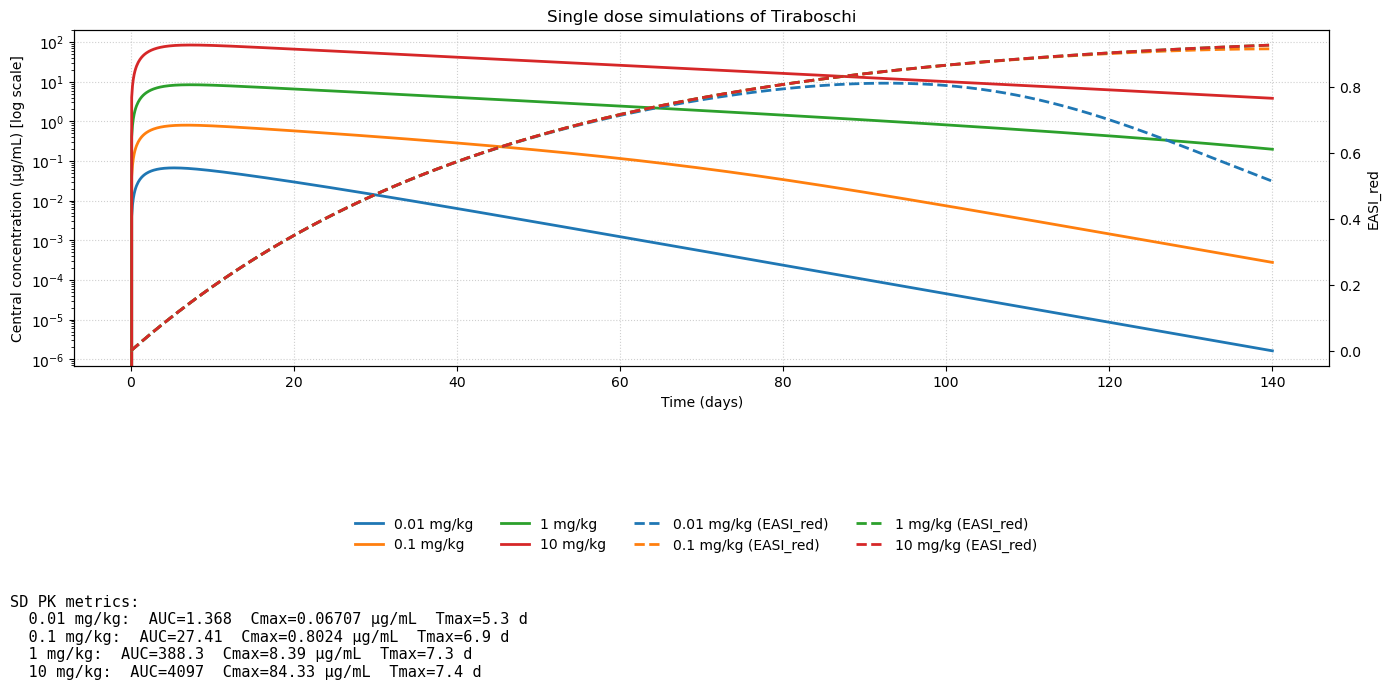

In [23]:
import matplotlib.lines as mlines

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_yscale("log")
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Central concentration (µg/mL) [log scale]")
ax1.grid(True, linestyle=":", alpha=0.6)

ax2 = None  # created only if PD exists

# Create a deterministic color map: one color per dose (Matplotlib default cycle)
doses_sorted = sorted({float(r["dose_mgkg"]) for r in runs})
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
dose_to_color = {d: prop_cycle[i % len(prop_cycle)] for i, d in enumerate(doses_sorted)}

# For symmetric legend
pk_handles, pd_handles = [], []
pd_key_seen = None

sd_metrics = []

for r in runs:
    run_dir = r["run_dir"]
    h5_path = run_dir / "run.h5"
    if not h5_path.exists():
        raise FileNotFoundError(f"Missing run.h5 in:\n  {run_dir}")

    t, pk_vals, pd_vals, pk_key, pd_key = read_timecourse_from_h5(h5_path)

    d = float(r["dose_mgkg"])
    pw = int(r.get("time_weeks", r.get("interval_weeks", time_weeks)))
    c = dose_to_color[d]

    # PK line (solid) with per-dose color
    ax1.plot(t, pk_vals, linewidth=2, color=c)

    # Add PK legend handle (one per dose)
    pk_handles.append(
        mlines.Line2D([], [], color=c, lw=2, linestyle="-", label=f"{d:g} mg/kg")
    )

    # PD line (dashed) with SAME color as PK line
    if pd_vals is not None:
        if ax2 is None:
            ax2 = ax1.twinx()
            ax2.set_ylabel(pd_key or "PD (unitless)")
        ax2.plot(t, pd_vals, linewidth=2, linestyle="--", color=c)

        pd_key_seen = pd_key_seen or (pd_key or "PD")
        pd_handles.append(
            mlines.Line2D([], [], color=c, lw=2, linestyle="--", label=f"{d:g} mg/kg ({pd_key_seen})")
        )

    if T_END_MODE == "SS":
        Iota_days = pw * 7
        dose_times = np.arange(0, 25 * Iota_days + 1e-9, Iota_days)
        for td in dose_times:
            ax1.axvline(td, linewidth=0.7, alpha=0.15)
    else:
        AUC = auc_trapz(t, pk_vals)
        Cmax = float(np.max(pk_vals))
        Tmax = float(t[np.argmax(pk_vals)])
        sd_metrics.append({"dose": d, "AUC": AUC, "Cmax": Cmax, "Tmax": Tmax})

# Titles
if T_END_MODE == "SS":
    title = f"Steady state simulation of {MODEL} for {doses_sorted[0]:g} mg/kg dosing at q{time_weeks}w"
else:
    title = f"Single dose simulations of {MODEL}"
plt.title(title)

# ---------- Symmetric legend (two rows: PK then PD) ----------
# If no PD was plotted, just show PK row.
handles = pk_handles + (pd_handles if len(pd_handles) else [])

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(pk_handles),          # makes it symmetric across doses
    frameon=False,
)

# Summary text under plot (unchanged from your version)
if T_END_MODE == "SS":
    summary_text = format_ss_summary(runs[0]["summary"], cfg)
else:
    summary_text = format_sd_summary(sd_metrics)

fig.text(
    0.01, -0.20,
    summary_text,
    ha="left", va="top",
    fontsize=11,
    family="monospace",
)

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()

